# 03 – Forecasting Models: Single-Plant, Single-Day Day-Ahead Setup

Dieses Notebook simuliert den realen Bidding-Alltag: Für jeden ausgewählten Zieltag wird mit den letzten 30 bzw. 90 Tagen davor neu trainiert und ein 24h-Day-Ahead-Forecast erzeugt.

## Zwei Szenarien

| Szenario | Features | Beschreibung |
|---|---|---|
| **Historical** | SCADA-Lags (lag_24/48, Rolling Means, Zeitfeatures) | Nur historische Produktionsdaten, keine Wettervorhersage |
| **NWP** | NWP-Vorhersage + SCADA-Lags | Echte Wettervorhersagedaten (Wind 100m, Temperatur, Druck, Bewölkung) als Hauptfeature |

Der Vergleich zeigt direkt, wie viel Mehrwert echte Wettervorhersagedaten gegenüber reinen historischen Daten bringen.

## Designentscheidungen

**Ein Standort:** Schonungen — längste verfügbare Zeitreihe (2014–2025).

**Rolling Retraining:** Für jeden Zieltag wird mit den Tagen davor neu trainiert (kein Blick in die Zukunft). Trainingsfenster: 30 und 90 Tage im Vergleich.

**12 Beispieltage:** Je 1 ruhiger, 1 durchschnittlicher und 1 windiger Tag pro Jahreszeit — automatisch anhand der Windgeschwindigkeit ausgewählt (Quantile 0.25/0.50/0.75), kein Cherry-Picking.

## 1. Setup und Imports

In [37]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FORECAST_DIR  = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"

for d in [FORECAST_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from src.models import elastic_net
from src.models import random_forest
from src.models import gradient_boosting
from src.models import xgboost_model
from src.models import quantile_regression
from src.models import quantile_regression_forest
from src.models import quantile_gradient_boosting
from src.models import quantile_xgboost
from src.models import arima

from src.data.load_nwp import load_and_merge_nwp, FEATURES_HISTORICAL, FEATURES_NWP

print("Project root:", PROJECT_ROOT)


Project root: /Users/noahweis/wind_bidding_project


## 2. Parameter

Zentrale Konfiguration — hier wird Standort, Trainingsfenster und die Liste der Zieltage festgelegt.

In [38]:
SELECTED_PLANT       = "Schonungen"
TRAINING_WINDOW_DAYS = 30  # Vergleich: kurzes vs. langes Rolling-Window
TRAINING_WINDOW_DAYS_LIST = [30]  # nur 30 Tage — Fokus auf Szenariovergleich (historical vs. nwp)
HORIZON_HOURS        = 24
QUANTILES            = [0.10, 0.25, 0.50, 0.75, 0.90]

# Zwei Szenarien: mit und ohne NWP-Wettervorhersagedaten
# Szenario A: nur historische SCADA-Lags (30 Tage) -- "ohne Wettervorhersage"
# Szenario B: NWP-Features + SCADA-Lags             -- "mit Wettervorhersage"
SCENARIOS = {
    "historical": FEATURES_HISTORICAL,
    "nwp":        FEATURES_NWP,
}

# 8 begründet ausgewählte Zieltage: je 1 windreicher + 1 windschwacher Tag pro Jahreszeit
TARGET_DAYS = {
    "Fruehling_windig": "2022-04-07",
    "Fruehling_ruhig":  "2025-03-05",
    "Sommer_windig":    "2020-08-26",
    "Sommer_ruhig":     "2021-06-10",
    "Herbst_windig":    "2021-10-21",
    "Herbst_ruhig":     "2023-09-10",
    "Winter_windig":    "2020-02-10",
    "Winter_ruhig":     "2020-01-25",
}

print(f"Standort: {SELECTED_PLANT}")
print(f"Trainingsfenster: {TRAINING_WINDOW_DAYS} Tage")
print(f"Anzahl Zieltage: {len(TARGET_DAYS)}")

Standort: Schonungen
Trainingsfenster: 30 Tage
Anzahl Zieltage: 8


## Automatische Auswahl geeigneter Beispiel-Tage

Statt nur sehr windige oder sehr ruhige Tage manuell auszuwählen, werden hier geeignete Beispiel-Tage anhand der täglichen Windgeschwindigkeit gesucht.

Die Idee:

- **ruhiger Tag**: niedrige, aber nicht extreme Windgeschwindigkeit
- **durchschnittlicher Tag**: nahe am Median
- **windiger Tag**: hohe, aber nicht extreme Windgeschwindigkeit

Damit vermeidet man extreme Ausreißertage, die oft schwer vorherzusagen sind und als Beispielgrafik unfair wirken können.

Wichtig: Die Tage werden nur als Zieltag ausgewählt. Das Training verwendet weiterhin nur Daten **vor** dem jeweiligen Zieltag.


In [39]:
# -------------------------------------------------------------------
# Day selection mode
# -------------------------------------------------------------------
# "manual"  -> TARGET_DAY wird manuell genutzt
# "calm"    -> ruhiger, aber nicht extremer Tag
# "average" -> durchschnittlicher Windtag
# "windy"   -> windiger, aber nicht extremer Tag
#
# Empfehlung:
# Für erste saubere Plots: DAY_TYPE = "average"
# Für Vergleich im Paper: einmal "calm", einmal "average", einmal "windy"
# -------------------------------------------------------------------

DAY_TYPE = "average"   # "manual", "calm", "average", "windy"

# Damit das Training vor dem Zieltag genug Daten hat
MIN_HISTORY_DAYS = TRAINING_WINDOW_DAYS + 8

# Damit einzelne Datenlücken nicht direkt einen Tag kaputt machen
MIN_HOURS_PER_DAY = 20

# Ausreißer vermeiden:
# Wir wählen nicht exakt Minimum/Maximum, sondern robuste Quantilbereiche.
DAY_SELECTION_QUANTILES = {
    "calm": 0.25,
    "average": 0.50,
    "windy": 0.75,
}


In [40]:
def select_representative_target_day(
    df_plant: pd.DataFrame,
    day_type: str,
    wind_col: str = "wind_speed",
    target_col: str = "power",
    min_history_days: int = 38,
    min_hours_per_day: int = 20,
) -> tuple[str, pd.DataFrame]:
    """
    Select a representative target day for a selected wind plant.

    The selected day is based on daily mean wind speed:
    - calm: near 25th percentile
    - average: near 50th percentile
    - windy: near 75th percentile

    This avoids selecting extreme outlier days.
    """

    if wind_col not in df_plant.columns:
        raise ValueError(f"'{wind_col}' fehlt. Tagesauswahl nach Windgeschwindigkeit nicht möglich.")

    df_tmp = df_plant.copy()
    df_tmp["date"] = df_tmp["timestamp"].dt.date

    daily = (
        df_tmp
        .groupby("date")
        .agg(
            mean_wind_speed=(wind_col, "mean"),
            median_wind_speed=(wind_col, "median"),
            std_wind_speed=(wind_col, "std"),
            mean_power=(target_col, "mean"),
            hours=("timestamp", "count"),
            start=("timestamp", "min"),
            end=("timestamp", "max"),
        )
        .reset_index()
    )

    daily["date"] = pd.to_datetime(daily["date"])

    daily = daily[daily["hours"] >= min_hours_per_day].copy()

    min_allowed_day = df_tmp["timestamp"].min().normalize() + pd.Timedelta(days=min_history_days)
    max_allowed_day = df_tmp["timestamp"].max().normalize()

    daily = daily[
        (daily["date"] >= min_allowed_day)
        & (daily["date"] <= max_allowed_day)
    ].copy()

    if daily.empty:
        raise ValueError(
            "Keine geeigneten Tage gefunden. Prüfe MIN_HISTORY_DAYS, MIN_HOURS_PER_DAY oder den Datenzeitraum."
        )

    if day_type not in DAY_SELECTION_QUANTILES:
        raise ValueError(f"day_type muss einer von {list(DAY_SELECTION_QUANTILES.keys())} sein.")

    target_quantile = DAY_SELECTION_QUANTILES[day_type]
    target_wind = daily["mean_wind_speed"].quantile(target_quantile)

    daily["distance_to_target_wind"] = (daily["mean_wind_speed"] - target_wind).abs()

    selected_row = (
        daily
        .sort_values(["distance_to_target_wind", "std_wind_speed"])
        .iloc[0]
    )

    selected_day = selected_row["date"].strftime("%Y-%m-%d")

    return selected_day, daily.sort_values("mean_wind_speed").reset_index(drop=True)


In [41]:
# Zufällige Tagesauswahl: N Tage nach NWP-Start (2017-02-05)
# Mindestanforderung: vollständige 24 Stunden, genug Trainingsdaten davor
NWP_START      = pd.Timestamp("2017-02-05")  # mind. 30 Tage nach NWP-Start 2017-01-01
N_TARGET_DAYS  = 60   # Anzahl zufälliger Zieltage
RANDOM_SEED    = 42

# Alle vollständigen Tage nach NWP_START ermitteln
df_tmp = df[df["timestamp"] >= NWP_START].copy()
df_tmp["date"] = df_tmp["timestamp"].dt.date
daily_counts = df_tmp.groupby("date")["timestamp"].count()
full_days = daily_counts[daily_counts >= 24].index.tolist()

# Nur Tage mit genug Trainingsdaten (mind. 30 Tage vorher im Dataset)
valid_days = [
    d for d in full_days
    if pd.Timestamp(d) - pd.Timedelta(days=30) >= df["timestamp"].min()
]

# Zufällig N Tage ziehen
import random
random.seed(RANDOM_SEED)
selected = sorted(random.sample(valid_days, min(N_TARGET_DAYS, len(valid_days))))

TARGET_DAYS = {str(d): str(d) for d in selected}

print(f"Verfügbare vollständige Tage: {len(valid_days)}")
print(f"Ausgewählte Zieltage: {len(TARGET_DAYS)}")
print(f"Zeitraum: {selected[0]} bis {selected[-1]}")
print(f"Erste 5 Tage: {selected[:5]}")

  Winter_calm: 2018-01-27
  Winter_average: 2023-01-24
  Winter_windy: 2023-02-25
  Fruehling_calm: 2025-04-30
  Fruehling_average: 2018-03-04
  Fruehling_windy: 2021-05-17
  Sommer_calm: 2018-07-11
  Sommer_average: 2024-08-10
  Sommer_windy: 2018-08-01
  Herbst_calm: 2017-10-16
  Herbst_average: 2021-10-01
  Herbst_windy: 2023-10-18

Gesamt: 12 Zieltage ausgewählt


## Übersicht: ruhige, durchschnittliche und windige Kandidaten

Diese Tabelle hilft dir, bewusst Beispiel-Tage auszuwählen.

Für die Arbeit ist es sinnvoll, nicht nur den einfachsten Tag zu zeigen, sondern mindestens einen ruhigen, einen durchschnittlichen und einen windigen Tag zu vergleichen.


In [42]:
# Kandidatentage-Übersicht: Windverteilung der ausgewählten Tage
df_tmp2 = df[df["timestamp"] >= NWP_START].copy()
df_tmp2["date"] = df_tmp2["timestamp"].dt.date
daily_wind = df_tmp2.groupby("date")["wind_speed"].mean().reset_index()
daily_wind.columns = ["date", "mean_wind_speed"]
daily_wind["date"] = pd.to_datetime(daily_wind["date"])
daily_wind["selected"] = daily_wind["date"].dt.strftime("%Y-%m-%d").isin(TARGET_DAYS.keys())

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(
    daily_wind[~daily_wind["selected"]]["date"],
    daily_wind[~daily_wind["selected"]]["mean_wind_speed"],
    s=5, color="lightgray", label="Nicht ausgewählt", zorder=1
)
ax.scatter(
    daily_wind[daily_wind["selected"]]["date"],
    daily_wind[daily_wind["selected"]]["mean_wind_speed"],
    s=20, color="steelblue", label=f"Ausgewählt (n={len(TARGET_DAYS)})", zorder=2
)
ax.set_ylabel("Mittlere Windgeschwindigkeit [m/s]")
ax.set_title(f"Zufällig ausgewählte Zieltage (n={len(TARGET_DAYS)}) — Windverteilung")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Wind-Stats der ausgewählten Tage:")
sel_wind = daily_wind[daily_wind["selected"]]["mean_wind_speed"]
print(f"  Mittel: {sel_wind.mean():.2f} m/s | Std: {sel_wind.std():.2f} | Min: {sel_wind.min():.2f} | Max: {sel_wind.max():.2f}")

,day_type,date,mean_wind_speed,median_wind_speed,std_wind_speed,mean_power,hours
0,average,2016-03-31,4.870972,3.540000,3.054813,440.376389,24
1,average,2020-01-07,4.871667,4.681667,0.994678,230.147222,24
2,average,2025-07-04,4.872306,3.676667,1.957666,285.019722,24
3,average,2015-06-06,4.872361,4.673333,1.464887,225.109722,24
4,average,2015-11-08,4.872361,4.926667,2.041689,300.001389,24
5,calm,2018-06-26,3.735000,2.996667,1.537651,125.204167,24
6,calm,2025-07-20,3.734861,3.715000,1.945255,148.122222,24
7,calm,2015-09-03,3.735417,3.613333,0.960106,70.558333,24
8,calm,2022-07-02,3.736111,3.840000,0.952536,53.895833,24
9,calm,2021-03-23,3.732917,3.645000,0.592710,81.700000,24


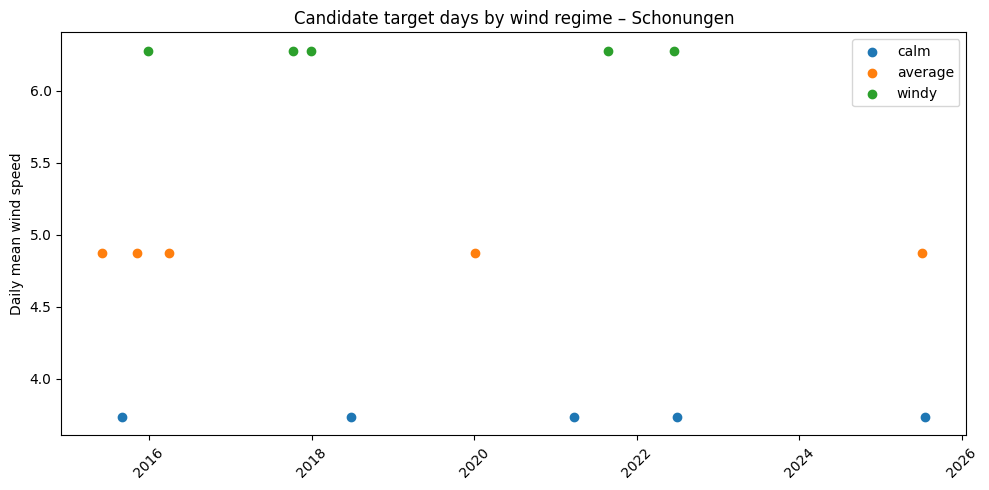

In [43]:
plt.figure(figsize=(10, 5))

for day_type in ["calm", "average", "windy"]:
    subset = candidate_days[candidate_days["day_type"] == day_type]
    plt.scatter(
        subset["date"],
        subset["mean_wind_speed"],
        label=day_type,
    )

plt.xticks(rotation=45)
plt.ylabel("Daily mean wind speed")
plt.title(f"Candidate target days by wind regime – {SELECTED_PLANT}")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Daten laden und auf den ausgewählten Standort filtern

Wichtig: Erst filtern, DANN Lag-Features bauen — sonst könnten Lags versehentlich von einem anderen Standort stammen.

In [44]:
df_all = pd.read_csv(PROCESSED_DIR / "final_dataset.csv", parse_dates=["timestamp"])

df = df_all[df_all["site"] == SELECTED_PLANT].copy()
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Datensatz für {SELECTED_PLANT}: {df.shape}")
print(f"Zeitraum: {df['timestamp'].min()} bis {df['timestamp'].max()}")

# Lückenprüfung
full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing = full_range.difference(df["timestamp"])
print(f"Fehlende Stunden: {len(missing)} von {len(full_range)}")

Datensatz für Schonungen: (98357, 11)
Zeitraum: 2014-01-02 00:00:00 bis 2025-08-31 23:00:00
Fehlende Stunden: 3883 von 102240


## 4. Feature Engineering (Lags) — NACH dem Standort-Filter

In [45]:
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Baut Day-Ahead-konforme Lag-Features. Nur Informationen die
    24h vor der Zielstunde bereits verfügbar wären.
    """
    df = df.copy()
    df["energy_lag_24"]     = df["power"].shift(24)
    df["energy_lag_48"]     = df["power"].shift(48)
    df["wind_speed_lag_24"] = df["wind_speed"].shift(24)
    df["energy_roll_mean_72"]  = df["power"].shift(24).rolling(72).mean()
    df["wind_roll_mean_72"]    = df["wind_speed"].shift(24).rolling(72).mean()
    return df

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "timestamp" not in df.columns:
        raise ValueError("timestamp column is required to create time features")
    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    return df

df = add_lag_features(df)
df = add_time_features(df)

TARGET = "power"

# NWP-Daten einmergen (lag_0 = echte Vorhersage fuer Zielstunde)
df = load_and_merge_nwp(df, site=SELECTED_PLANT)

# Alle benoetigten Features aus beiden Szenarien fuer dropna nutzen
ALL_FEATURES = list(set(FEATURES_HISTORICAL + FEATURES_NWP))

df_model = df.dropna(subset=ALL_FEATURES + [TARGET]).reset_index(drop=True)
print(f"Nach Lag-Feature-Erstellung, NWP-Merge und Dropna: {df_model.shape}")
print(f"NWP-Daten vorhanden: {df_model['nwp_ws100'].notna().sum()} Stunden")


NWP geladen (Schonungen): 75,960 Stunden | 2017-01-01 bis 2025-08-31
Nach Lag-Feature-Erstellung, NWP-Merge und Dropna: (75129, 24)
NWP-Daten vorhanden: 75129 Stunden


/Users/noahweis/wind_bidding_project/src/data/load_nwp.py:213: UserWarning: 23228 Stunden ohne NWP-Daten (23.6%).
  warnings.warn(


## 5. Rolling-Training-Funktion

Für jeden Zieltag: Trainingsdaten = die `TRAINING_WINDOW_DAYS` Tage direkt davor. Alle Modelle werden neu trainiert, dann wird der 24h-Forecast für den Zieltag erzeugt.

In [46]:
def get_train_test_window(
    df_model: pd.DataFrame,
    target_day: str,
    window_days: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Gibt (train_df, test_df) für einen Zieltag zurück.
    train_df: die window_days Tage VOR dem Zieltag.
    test_df:  die 24 Stunden DES Zieltags.
    """
    target_start = pd.Timestamp(target_day)
    target_end   = target_start + pd.Timedelta(hours=23)
    train_start  = target_start - pd.Timedelta(days=window_days)
    train_end    = target_start - pd.Timedelta(hours=1)

    train_df = df_model[
        (df_model["timestamp"] >= train_start) & (df_model["timestamp"] <= train_end)
    ].copy()
    test_df = df_model[
        (df_model["timestamp"] >= target_start) & (df_model["timestamp"] <= target_end)
    ].copy()

    return train_df, test_df


# Sanity-Check mit einem der neuen Keys
_first_key = list(TARGET_DAYS.keys())[0]
_train_check, _test_check = get_train_test_window(df_model, TARGET_DAYS[_first_key], window_days=30)
print(f"Beispieltag: {_first_key} → {TARGET_DAYS[_first_key]}")
print(f"Train: {len(_train_check)} Stunden ({_train_check['timestamp'].min()} bis {_train_check['timestamp'].max()})")
print(f"Test:  {len(_test_check)} Stunden ({_test_check['timestamp'].min()} bis {_test_check['timestamp'].max()})")

Beispieltag: Winter_calm → 2018-01-27
Train: 720 Stunden (2017-12-28 00:00:00 bis 2018-01-26 23:00:00)
Test:  24 Stunden (2018-01-27 00:00:00 bis 2018-01-27 23:00:00)


## 6. Alle Modelle für einen Tag trainieren

Diese Funktion trainiert alle Point- und Quantile-Modelle auf dem 30-Tage-Fenster und erzeugt die 24h-Forecasts.

In [47]:
def run_single_day(target_day: str, day_label: str, window_days: int, scenario: str = "historical") -> pd.DataFrame:
    """
    Trainiert alle Modelle auf den TRAINING_WINDOW_DAYS Tagen vor target_day
    und erzeugt 24h-Forecasts für target_day.

    Returns
    -------
    pd.DataFrame mit einer Zeile pro Stunde des Zieltags und einer Spalte
    pro Modell/Quantil.
    """
    train_df, test_df = get_train_test_window(df_model, target_day, window_days=window_days)

    if len(test_df) < HORIZON_HOURS:
        warnings.warn(f"{day_label}: nur {len(test_df)} Stunden im Testfenster, erwartet {HORIZON_HOURS}.")
    if len(train_df) < window_days * 24 * 0.8:
        warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")

    features = SCENARIOS[scenario]
    X_train, y_train = train_df[features], train_df[TARGET]
    X_test,  y_test  = test_df[features],  test_df[TARGET]

    result = pd.DataFrame({
        "timestamp": test_df["timestamp"].values,
        "day_label": day_label,
        "window_days": window_days,
        "scenario": scenario,
        "y_true": y_test.values,
    })

    # --- Persistence 24h ---
    result["persistence_24h"] = X_test["energy_lag_24"].to_numpy()

    # --- Elastic Net ---
    en_model = elastic_net.train(X_train, y_train)
    result["elastic_net"] = elastic_net.predict(en_model, X_test, clip_negative=True)

    # --- Random Forest ---
    # Bei nur ~720 Trainingsstunden braucht der Wald weniger, flachere Baeume
    # mit kleinerem min_samples_leaf, sonst kollabieren die Vorhersagen auf
    # wenige Blattwerte (zu starke Regularisierung fuer so wenig Daten).
    # Komplexität skaliert leicht mit der Trainingsfenstergröße:
    # bei 90 Tagen (mehr Daten) sind tiefere Bäume robuster moeglich als bei 30 Tagen.
    rf_max_depth = 6 if window_days <= 30 else 8
    rf_model = random_forest.train(
        X_train, y_train,
        n_estimators=200, max_depth=rf_max_depth, min_samples_leaf=2,
        random_state=42,
    )
    result["random_forest"] = random_forest.predict(rf_model, X_test, clip_negative=True)

    # --- Gradient Boosting ---
    gb_max_depth = 3 if window_days <= 30 else 4
    gb_model = gradient_boosting.train(
        X_train, y_train,
        n_estimators=150, learning_rate=0.05, max_depth=gb_max_depth, min_samples_leaf=3,
        random_state=42,
    )
    result["gradient_boosting"] = gradient_boosting.predict(gb_model, X_test, clip_negative=True)

    # --- XGBoost ---
    xgb_max_depth = 3 if window_days <= 30 else 4
    xgb_model = xgboost_model.train(
        X_train, y_train,
        n_estimators=150, learning_rate=0.05, max_depth=xgb_max_depth, min_child_weight=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42,
    )
    result["xgboost"] = xgboost_model.predict(xgb_model, X_test, clip_negative=True)

    # --- ARIMA (nur Zielreihe) ---
    # Nutzt eure eigene arima.py: train() schaetzt (p,d,q) automatisch via auto_arima
    # (Fallback auf festen Default falls pmdarima nicht installiert ist).
    try:
        arima_fitted = arima.train(y_train.to_numpy())
        y_pred_arima = arima.predict(arima_fitted, steps=len(y_test))
        result["arima"] = np.clip(y_pred_arima, 0, None)
    except Exception as e:
        warnings.warn(f"{day_label}: ARIMA fehlgeschlagen ({e}), fülle mit NaN.")
        result["arima"] = np.nan

    # --- Quantile Regression ---
    qr_models = quantile_regression.train(X_train, y_train, quantiles=QUANTILES)
    qr_preds  = quantile_regression.predict_all(qr_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"quantile_regression_{col}"] = qr_preds[col].values

    # --- QRF ---
    qrf_model = quantile_regression_forest.train(X_train, y_train, random_state=42)
    qrf_preds = quantile_regression_forest.predict_all(qrf_model, X_test, quantiles=QUANTILES, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qrf_{col}"] = qrf_preds[col].values

    # --- QGB ---
    qgb_models = quantile_gradient_boosting.train(
        X_train, y_train, quantiles=QUANTILES,
        n_estimators=150, learning_rate=0.05, max_depth=3, min_samples_leaf=3,
        random_state=42,
    )
    qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qgb_{col}"] = qgb_preds[col].values

    # --- Quantile XGBoost ---
    qxgb_models = quantile_xgboost.train(
        X_train, y_train, quantiles=QUANTILES,
        n_estimators=150, learning_rate=0.05, max_depth=3, min_child_weight=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42,
    )
    qxgb_preds = quantile_xgboost.predict_all(qxgb_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qxgb_{col}"] = qxgb_preds[col].values

    return result

## 7. Für alle 8 Zieltage durchlaufen

**Hinweis:** Dies trainiert alle Modelle 8 mal neu (einmal pro Zieltag). Bei 30 Trainingstagen ist das deutlich schneller als ein Training auf dem vollen mehrjährigen Datensatz.

In [48]:
all_results = []
window_days_values = TRAINING_WINDOW_DAYS_LIST if 'TRAINING_WINDOW_DAYS_LIST' in globals() else [TRAINING_WINDOW_DAYS]

for scenario in SCENARIOS:
    for window_days in window_days_values:
        print(f"\n{'='*60}")
        print(f"SZENARIO: {scenario.upper()} | FENSTER: {window_days} Tage")
        print(f"{'='*60}")

        for day_label, target_day in TARGET_DAYS.items():
            print(f"\n--- {day_label} ({target_day}) ---")
            try:
                day_result = run_single_day(
                    target_day, day_label,
                    window_days=window_days,
                    scenario=scenario,
                )
                all_results.append(day_result)
                print(f"  OK: {len(day_result)} Stunden")
            except Exception as e:
                warnings.warn(f"{day_label} ({scenario}, {window_days}d): {e}")

predictions_single_day = pd.concat(all_results, ignore_index=True)
print(f"\nGesamt: {predictions_single_day.shape}")
predictions_single_day.head()


SZENARIO: HISTORICAL | FENSTER: 30 Tage

--- Winter_calm (2018-01-27) ---
  OK: 24 Stunden

--- Winter_average (2023-01-24) ---
  OK: 24 Stunden

--- Winter_windy (2023-02-25) ---
  OK: 24 Stunden

--- Fruehling_calm (2025-04-30) ---
  OK: 24 Stunden

--- Fruehling_average (2018-03-04) ---
  OK: 24 Stunden

--- Fruehling_windy (2021-05-17) ---
  OK: 24 Stunden

--- Sommer_calm (2018-07-11) ---
  OK: 24 Stunden

--- Sommer_average (2024-08-10) ---
  OK: 24 Stunden

--- Sommer_windy (2018-08-01) ---
  OK: 24 Stunden

--- Herbst_calm (2017-10-16) ---


/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_18386/2459222490.py:14: UserWarning: Herbst_calm: nur 22 Stunden im Testfenster, erwartet 24.
  warnings.warn(f"{day_label}: nur {len(test_df)} Stunden im Testfenster, erwartet {HORIZON_HOURS}.")
/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_18386/2459222490.py:16: UserWarning: Herbst_calm: nur 550 Trainingsstunden, erwartet ~720.
  warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")


  OK: 22 Stunden

--- Herbst_average (2021-10-01) ---
  OK: 24 Stunden

--- Herbst_windy (2023-10-18) ---
  OK: 24 Stunden

SZENARIO: NWP | FENSTER: 30 Tage

--- Winter_calm (2018-01-27) ---
  OK: 24 Stunden

--- Winter_average (2023-01-24) ---
  OK: 24 Stunden

--- Winter_windy (2023-02-25) ---
  OK: 24 Stunden

--- Fruehling_calm (2025-04-30) ---
  OK: 24 Stunden

--- Fruehling_average (2018-03-04) ---
  OK: 24 Stunden

--- Fruehling_windy (2021-05-17) ---
  OK: 24 Stunden

--- Sommer_calm (2018-07-11) ---
  OK: 24 Stunden

--- Sommer_average (2024-08-10) ---
  OK: 24 Stunden

--- Sommer_windy (2018-08-01) ---
  OK: 24 Stunden

--- Herbst_calm (2017-10-16) ---


/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_18386/2459222490.py:14: UserWarning: Herbst_calm: nur 22 Stunden im Testfenster, erwartet 24.
  warnings.warn(f"{day_label}: nur {len(test_df)} Stunden im Testfenster, erwartet {HORIZON_HOURS}.")
/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_18386/2459222490.py:16: UserWarning: Herbst_calm: nur 550 Trainingsstunden, erwartet ~720.
  warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")


  OK: 22 Stunden

--- Herbst_average (2021-10-01) ---
  OK: 24 Stunden

--- Herbst_windy (2023-10-18) ---
  OK: 24 Stunden

Gesamt: (572, 31)


,timestamp,day_label,window_days,scenario,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,xgboost,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qxgb_q10,qxgb_q25,qxgb_q50,qxgb_q75,qxgb_q90
0,2018-01-27 00:00:00,Winter_calm,30,historical,217.466667,479.433333,610.634087,500.177601,767.026569,734.414673,...,88.867718,301.501835,558.188733,1171.125416,1651.779830,111.534340,393.435333,535.150818,982.125122,1636.522827
1,2018-01-27 01:00:00,Winter_calm,30,historical,330.300000,357.000000,581.784821,511.662700,729.511586,711.594727,...,75.920780,290.749844,588.565043,1094.654685,1651.215420,98.346375,369.704895,511.574799,906.732178,1599.085205
2,2018-01-27 02:00:00,Winter_calm,30,historical,361.566667,708.366667,679.921271,761.713059,911.554910,900.588257,...,81.325009,286.079362,999.074803,1445.630860,1665.973035,95.058846,438.123871,886.822021,1319.885132,1674.152588
3,2018-01-27 03:00:00,Winter_calm,30,historical,320.866667,818.300000,707.001003,858.457058,927.294585,955.002502,...,103.091809,357.146546,1073.336029,1438.298877,1665.973035,99.156776,467.949829,964.318115,1368.990845,1671.867798
4,2018-01-27 04:00:00,Winter_calm,30,historical,272.100000,336.166667,566.016684,514.025870,714.413553,728.471069,...,90.590408,300.514351,540.439000,1047.404341,1651.215420,89.528038,389.564117,561.370361,862.223999,1601.495483


## 8. Speichern für Notebook 04

In [49]:
predictions_single_day.to_csv(FORECAST_DIR / "predictions_single_day.csv", index=False)
print("Gespeichert: predictions_single_day.csv")

Gespeichert: predictions_single_day.csv


## 9. Forecast-Metriken pro Modell (über alle 8 Tage zusammen)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

POINT_MODEL_COLS = ["persistence_24h", "elastic_net", "random_forest", "gradient_boosting", "xgboost", "arima"]

point_metrics_rows = []
for (scenario, window_days), grp in predictions_single_day.groupby(["scenario", "window_days"]):
    for col in POINT_MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() == 0:
            continue
        y_t = grp.loc[valid, "y_true"]
        y_p = grp.loc[valid, col]
        point_metrics_rows.append({
            "scenario":    scenario,
            "window_days": window_days,
            "model":       col,
            "MAE":         mean_absolute_error(y_t, y_p),
            "RMSE":        np.sqrt(mean_squared_error(y_t, y_p)),
            "R2":          r2_score(y_t, y_p),
        })

point_metrics_single_day = pd.DataFrame(point_metrics_rows).sort_values(["scenario", "window_days", "RMSE"])
point_metrics_single_day.to_csv(TABLES_DIR / "point_forecast_metrics_single_day.csv", index=False)
display(point_metrics_single_day)

,scenario,window_days,model,MAE,RMSE,R2
1,historical,30,elastic_net,215.668790,287.978515,0.148051
5,historical,30,arima,248.454770,338.299152,-0.175697
2,historical,30,random_forest,257.217935,341.798460,-0.200145
0,historical,30,persistence_24h,241.396620,369.040713,-0.399079
4,historical,30,xgboost,284.028041,371.905858,-0.420887
3,historical,30,gradient_boosting,292.800190,382.277524,-0.501243
8,nwp,30,random_forest,142.316310,198.722617,0.594316
10,nwp,30,xgboost,153.758849,212.756206,0.534995
7,nwp,30,elastic_net,152.944839,214.324884,0.528112
9,nwp,30,gradient_boosting,157.421496,218.441368,0.509811


## 10. Quantile-Band-Plot für einen Beispieltag

Zeigt für ein probabilistisches Modell (z.B. QNN-Gegenstück QXGB) den 24h-Verlauf mit Quantilband.

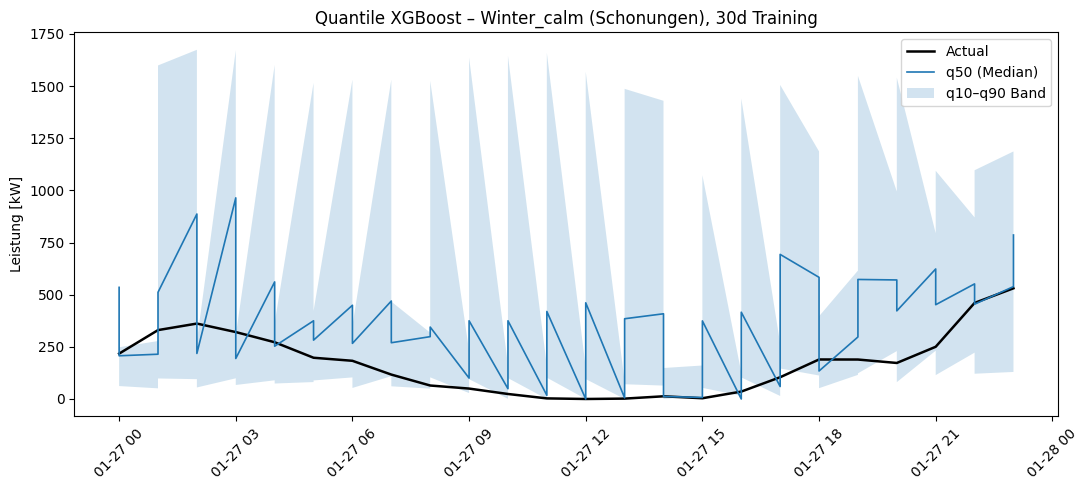

In [51]:
PLOT_DAY = list(TARGET_DAYS.keys())[0]  
PLOT_MODEL_PREFIX = "qxgb"

PLOT_WINDOW = 30  # welches Trainingsfenster fuer den Beispiel-Plot

day_data = predictions_single_day[
    (predictions_single_day["day_label"] == PLOT_DAY) &
    (predictions_single_day["window_days"] == PLOT_WINDOW)
].sort_values("timestamp")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(day_data["timestamp"], day_data["y_true"], label="Actual", color="black", linewidth=1.8)
ax.plot(day_data["timestamp"], day_data[f"{PLOT_MODEL_PREFIX}_q50"], label="q50 (Median)", linewidth=1.2)
ax.fill_between(
    day_data["timestamp"],
    day_data[f"{PLOT_MODEL_PREFIX}_q10"],
    day_data[f"{PLOT_MODEL_PREFIX}_q90"],
    alpha=0.2, label="q10–q90 Band",
)
ax.set_title(f"Quantile XGBoost – {PLOT_DAY} ({SELECTED_PLANT}), {PLOT_WINDOW}d Training")
ax.set_ylabel("Leistung [kW]")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / f"quantile_band_{PLOT_DAY}.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Vergleich: 30 Tage vs. 90 Tage Trainingsfenster

Hintergrund: Die Zieltage wurden bewusst als windreichste bzw. windschwächste Tage ihrer Saison gewählt. Bei einem kurzen Trainingsfenster (30 Tage) enthält die Trainingshistorie oft keine vergleichbar extremen Windverhältnisse — die Modelle müssen dann außerhalb des im Training beobachteten Wertebereichs extrapolieren. Ein längeres Fenster (90 Tage) erhöht die Chance, dass auch ähnlich extreme Tage im Training enthalten sind.

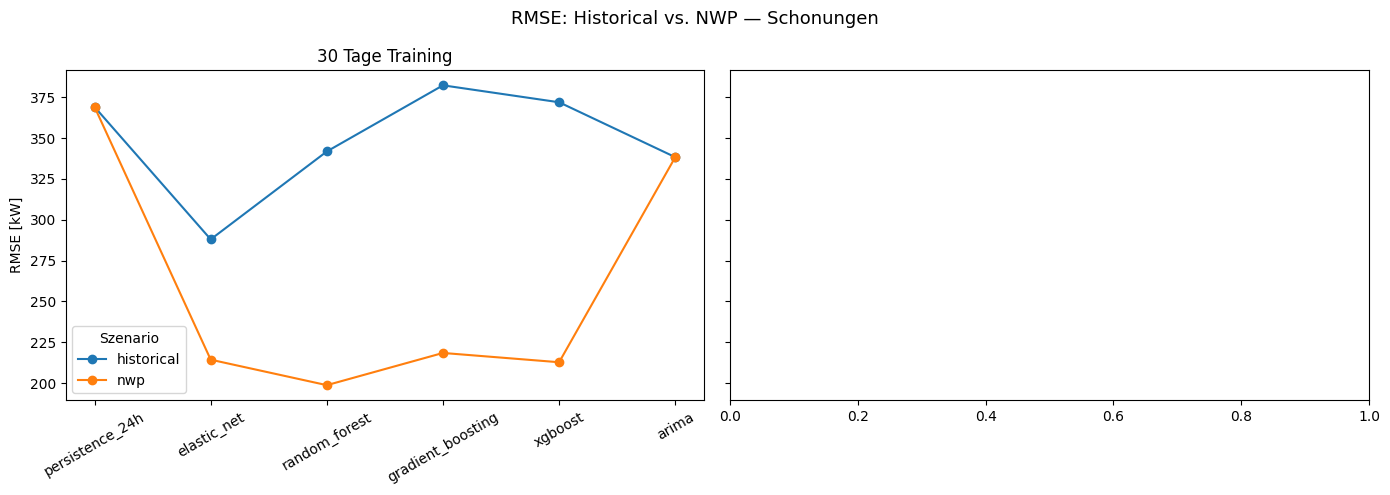

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, window_days in zip(axes, TRAINING_WINDOW_DAYS_LIST):
    grp_w = point_metrics_single_day[point_metrics_single_day["window_days"] == window_days]
    for scenario, grp_s in grp_w.groupby("scenario"):
        grp_sorted = grp_s.set_index("model").reindex(POINT_MODEL_COLS)
        ax.plot(grp_sorted.index, grp_sorted["RMSE"], marker="o", label=scenario)
    ax.set_title(f"{window_days} Tage Training")
    ax.set_ylabel("RMSE [kW]")
    ax.legend(title="Szenario")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle(f"RMSE: Historical vs. NWP — {SELECTED_PLANT}", fontsize=13)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / "scenario_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Forecast vs. Actual — alle 8 Beispieltage im Überblick

Zeigt für jeden der 8 Zieltage den tatsächlichen Verlauf gegen die wichtigsten Point-Forecasts (Persistence, Elastic Net, bestes Black-Box-Modell) sowie das Quantilband eines probabilistischen Modells. So wird sichtbar, wie gut (oder schlecht) die Modelle den Tagesverlauf der Windproduktion tatsächlich treffen — nicht nur als aggregierte Fehlerzahl, sondern visuell.

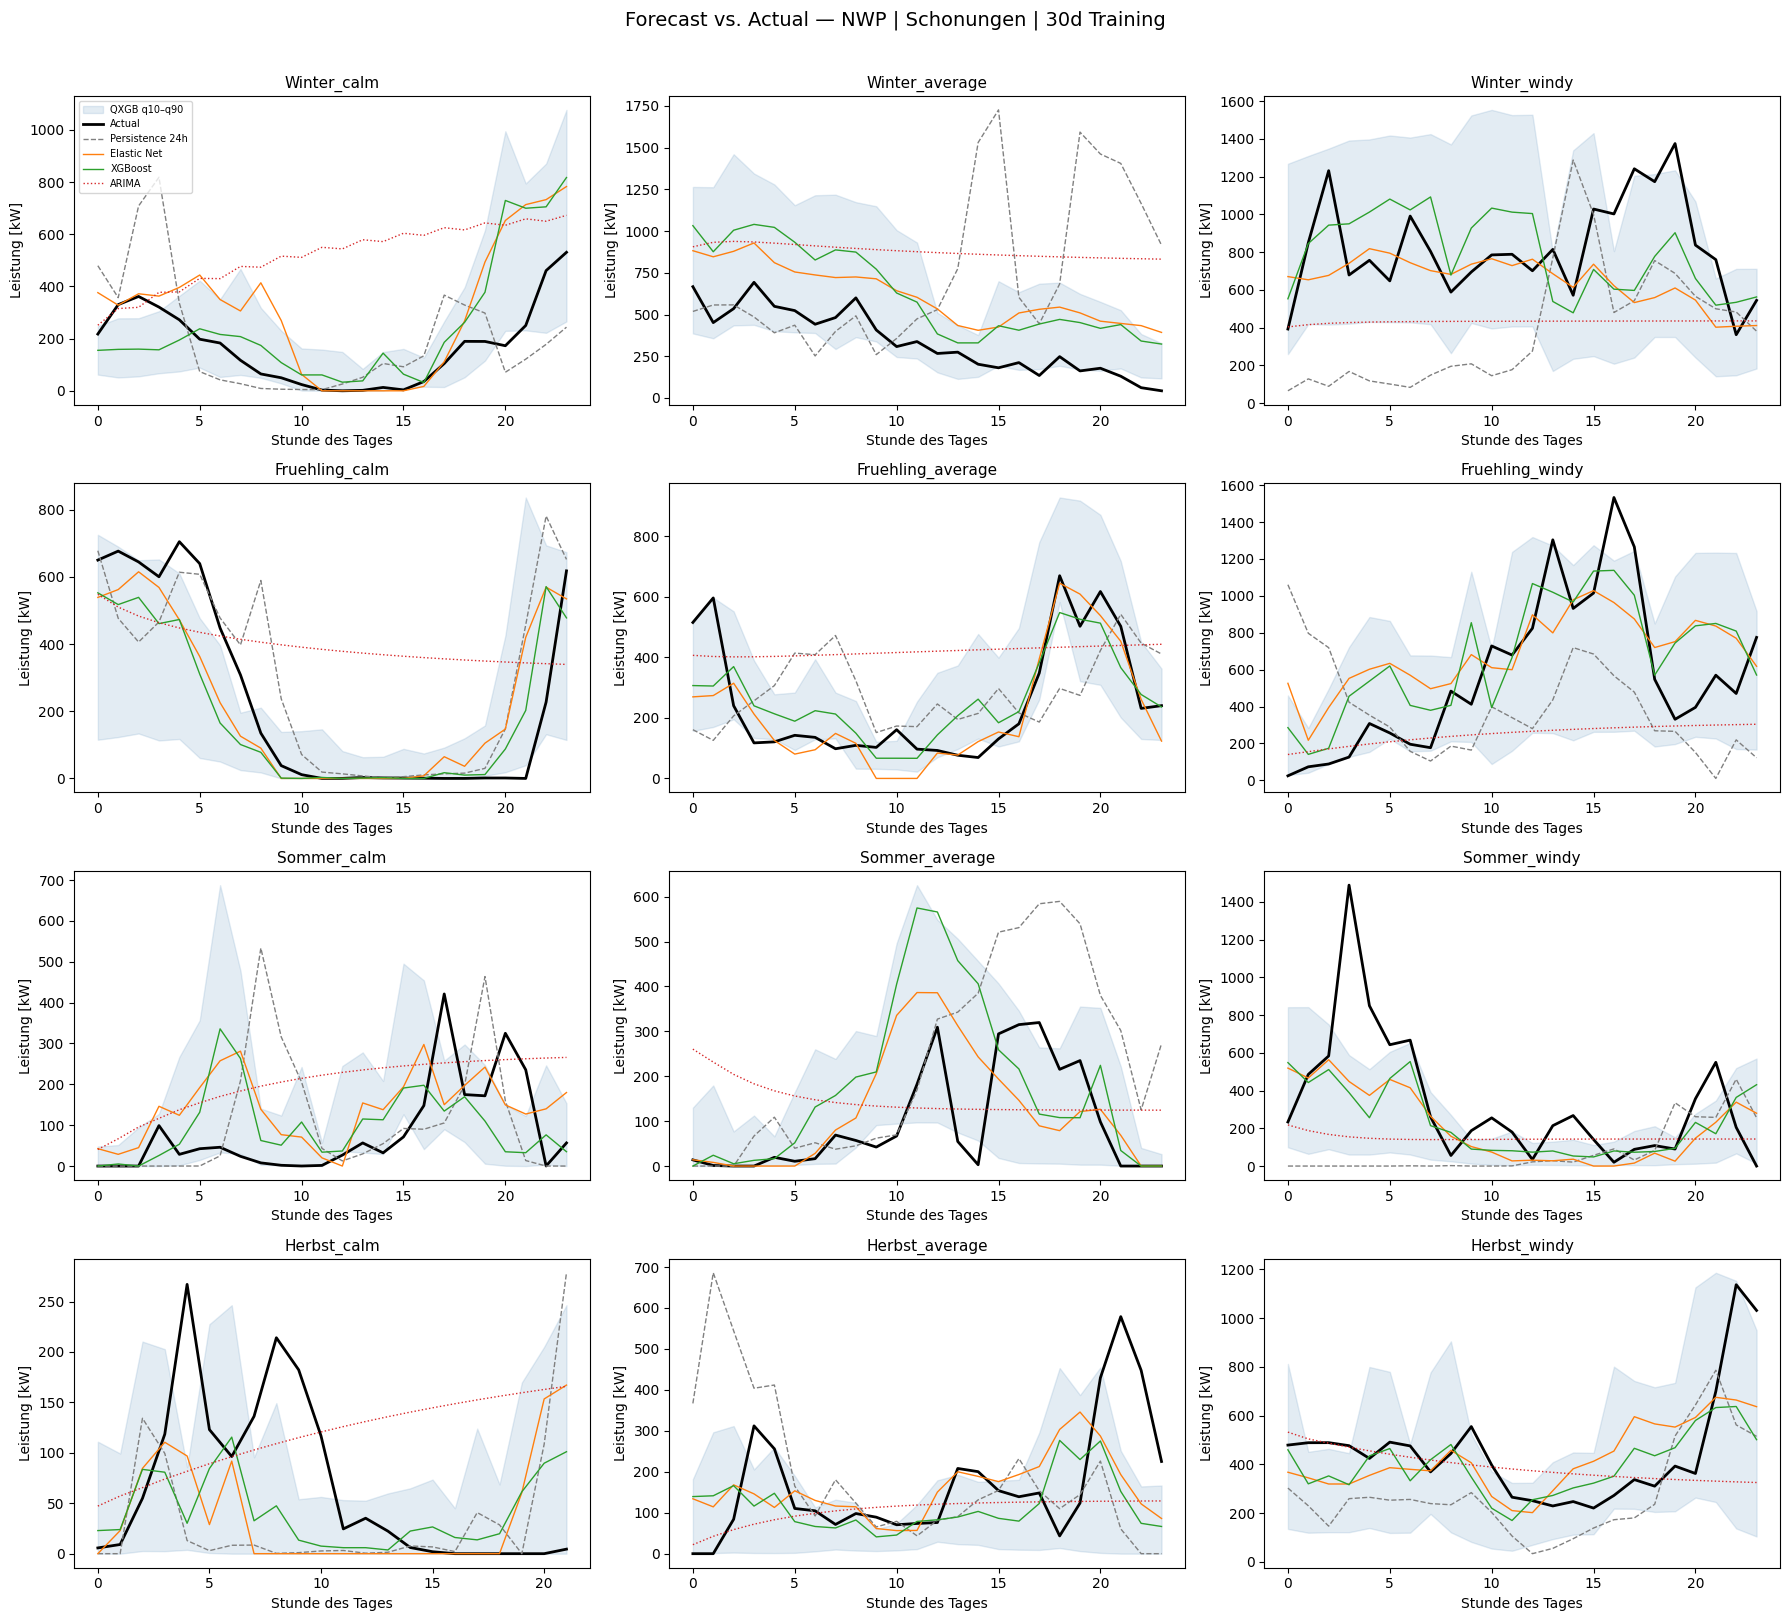

In [53]:
GRID_WINDOW    = 30       # welches Trainingsfenster
GRID_SCENARIO  = "nwp"    # "historical" oder "nwp"

day_order = list(TARGET_DAYS.keys())
n_days = len(day_order)

n_cols = 3
n_rows = (len(day_order) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
axes = axes.flatten()

for i, day_label in enumerate(day_order):
    ax = axes[i]
    d = predictions_single_day[
        (predictions_single_day["day_label"] == day_label) &
        (predictions_single_day["window_days"] == GRID_WINDOW) &
        (predictions_single_day["scenario"] == GRID_SCENARIO)
    ].sort_values("timestamp")

    if d.empty:
        ax.set_title(f"{day_label} (keine Daten)")
        continue

    hours = range(len(d))

    # Quantilband (QXGB) im Hintergrund
    ax.fill_between(hours, d["qxgb_q10"], d["qxgb_q90"], alpha=0.15, color="steelblue", label="QXGB q10–q90")

    ax.plot(hours, d["y_true"], color="black", linewidth=2, label="Actual")
    ax.plot(hours, d["persistence_24h"], color="gray", linestyle="--", linewidth=1, label="Persistence 24h")
    ax.plot(hours, d["elastic_net"], color="tab:orange", linewidth=1, label="Elastic Net")
    ax.plot(hours, d["xgboost"], color="tab:green", linewidth=1, label="XGBoost")
    ax.plot(hours, d["arima"], color="tab:red", linewidth=1, linestyle=":", label="ARIMA")

    ax.set_title(day_label, fontsize=11)
    ax.set_xlabel("Stunde des Tages")
    ax.set_ylabel("Leistung [kW]")

    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"Forecast vs. Actual — {GRID_SCENARIO.upper()} | {SELECTED_PLANT} | {GRID_WINDOW}d Training", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / f"forecast_vs_actual_grid_{GRID_SCENARIO}_{GRID_WINDOW}d.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Detailvergleich: 30 vs. 90 Tage Training an einem Extremtag

Zeigt explizit, ob ein längeres Trainingsfenster die Vorhersage am windreichsten Tag des Winters verbessert — also ob das Extrapolationsproblem durch mehr Trainingsdaten gemildert wird.

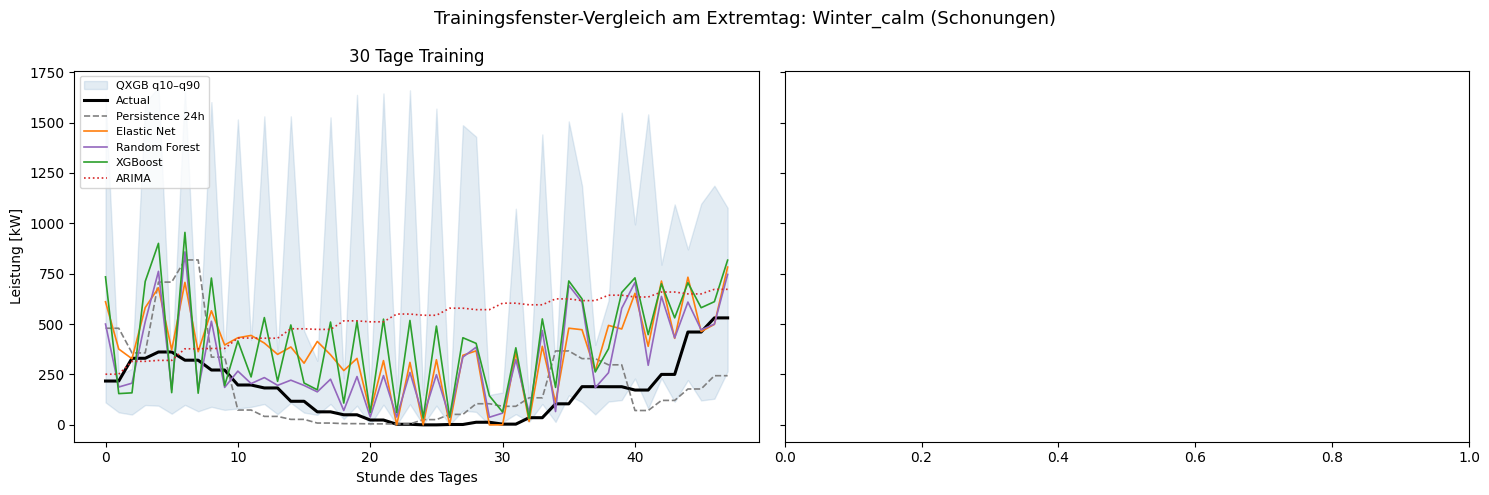

In [54]:
DETAIL_DAY = list(TARGET_DAYS.keys())[0]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, window_days in zip(axes, TRAINING_WINDOW_DAYS_LIST):
    d = predictions_single_day[
        (predictions_single_day["day_label"] == DETAIL_DAY) &
        (predictions_single_day["window_days"] == window_days)
    ].sort_values("timestamp")

    hours = range(len(d))

    ax.fill_between(hours, d["qxgb_q10"], d["qxgb_q90"], alpha=0.15, color="steelblue", label="QXGB q10–q90")
    ax.plot(hours, d["y_true"], color="black", linewidth=2.2, label="Actual")
    ax.plot(hours, d["persistence_24h"], color="gray", linestyle="--", linewidth=1.2, label="Persistence 24h")
    ax.plot(hours, d["elastic_net"], color="tab:orange", linewidth=1.2, label="Elastic Net")
    ax.plot(hours, d["random_forest"], color="tab:purple", linewidth=1.2, label="Random Forest")
    ax.plot(hours, d["xgboost"], color="tab:green", linewidth=1.2, label="XGBoost")
    ax.plot(hours, d["arima"], color="tab:red", linestyle=":", linewidth=1.2, label="ARIMA")

    ax.set_title(f"{window_days} Tage Training")
    ax.set_xlabel("Stunde des Tages")

axes[0].set_ylabel("Leistung [kW]")
axes[0].legend(fontsize=8, loc="upper left")

fig.suptitle(f"Trainingsfenster-Vergleich am Extremtag: {DETAIL_DAY} ({SELECTED_PLANT})", fontsize=13)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / f"window_detail_comparison_{DETAIL_DAY}.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
# ============================================================
# ERGEBNIS-EXPORT FÜR EVALUATION
# ============================================================
import json

eval_output = {}

# 1. Forecast-Metriken (alle Szenarien, Fenster, Modelle)
eval_output["point_metrics"] = point_metrics_single_day.to_dict(orient="records")

# 2. Verfügbare TARGET_DAYS
eval_output["target_days"] = TARGET_DAYS

# 3. Szenarien und Fenster die gelaufen sind
eval_output["scenarios_run"] = predictions_single_day["scenario"].unique().tolist()
eval_output["windows_run"]   = predictions_single_day["window_days"].unique().tolist()
eval_output["n_days"]        = predictions_single_day["day_label"].nunique()
eval_output["total_rows"]    = len(predictions_single_day)

# 4. Beispiel: bestes Modell pro Szenario (nach RMSE)
for scenario in predictions_single_day["scenario"].unique():
    grp = point_metrics_single_day[point_metrics_single_day["scenario"] == scenario]
    best = grp.sort_values("RMSE").iloc[0]
    eval_output[f"best_model_{scenario}"] = {
        "model": best["model"],
        "RMSE":  round(best["RMSE"], 4),
        "MAE":   round(best["MAE"], 4),
        "R2":    round(best["R2"], 4),
    }

# 5. Pinball-Metriken falls vorhanden
if "pinball_metrics" in dir() and pinball_metrics is not None:
    eval_output["pinball_metrics"] = pinball_metrics.to_dict(orient="records")

print(json.dumps(eval_output, indent=2, default=str))

{
  "point_metrics": [
    {
      "scenario": "historical",
      "window_days": 30,
      "model": "elastic_net",
      "MAE": 215.66879006499485,
      "RMSE": 287.97851517329025,
      "R2": 0.14805074790731665
    },
    {
      "scenario": "historical",
      "window_days": 30,
      "model": "arima",
      "MAE": 248.45476989596995,
      "RMSE": 338.299151890828,
      "R2": -0.17569688558543572
    },
    {
      "scenario": "historical",
      "window_days": 30,
      "model": "random_forest",
      "MAE": 257.21793452333384,
      "RMSE": 341.7984601796566,
      "R2": -0.20014509208658215
    },
    {
      "scenario": "historical",
      "window_days": 30,
      "model": "persistence_24h",
      "MAE": 241.39662004662006,
      "RMSE": 369.04071323166096,
      "R2": -0.39907859303038107
    },
    {
      "scenario": "historical",
      "window_days": 30,
      "model": "xgboost",
      "MAE": 284.028041487696,
      "RMSE": 371.9058578450279,
      "R2": -0.4208871529788